# Phase 2: Multi-Model Sentiment Scoring

**Models (3-tier architecture):**
- **Lexicon baseline:** VADER
- **General-purpose transformer:** RoBERTa-CardiffNLP (social/news)
- **Financial-domain transformers:** FinBERT, FinBERT-Tone, DistilRoBERTa-Financial

**Outputs:**
- `data/article_sentiments.csv` — per-article scores from all 5 models
- `data/daily_sentiment.csv` — daily aggregated scores, disagreement, article volume
- Plots: model comparison, early warning timeline, disagreement vs volatility

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

# Install dependencies
deps = [
    ("transformers", "transformers"),
    ("torch", "torch"),
    ("vaderSentiment", "vaderSentiment"),
    ("huggingface_hub", "huggingface_hub"),
]
for module, pkg in deps:
    try:
        __import__(module)
    except ImportError:
        print(f"Installing {pkg}...")
        !pip install {pkg} --quiet

import torch
from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from huggingface_hub import login

# ============================================================
# AUTH & DEVICE
# ============================================================
HF_TOKEN = "API-KEY-HERE"  # <-- paste your Hugging Face token
login(token=HF_TOKEN, add_to_git_credential=False)

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"Device: {DEVICE}")
print(f"HF login OK")

CRISIS_DATE = "2026-03-04"
BATCH_SIZE = 32
os.makedirs("plots", exist_ok=True)

# Model registry
MODEL_IDS = {
    "finbert":           "ProsusAI/finbert",
    "finbert_tone":      "yiyanghkust/finbert-tone",
    "distilroberta_fin": "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis",
    "roberta_general":   "cardiffnlp/twitter-roberta-base-sentiment-latest",
}
MODELS = ["vader", "finbert", "finbert_tone", "distilroberta_fin", "roberta_general"]
FIN_MODELS = ["finbert", "finbert_tone", "distilroberta_fin"]

Device: mps
HF login OK


In [2]:
# Load data
df = pd.read_csv("data/guardian_articles_clean.csv")
df["date"] = pd.to_datetime(df["date"]).dt.date
df["text_for_sentiment"] = df["text_for_sentiment"].fillna("")
df = df[df["text_for_sentiment"].str.strip().str.len() > 10].reset_index(drop=True)

prices = pd.read_csv("data/oil_prices.csv")
prices["date"] = pd.to_datetime(prices["date"]).dt.date

texts = df["text_for_sentiment"].tolist()

print(f"Articles: {len(df)}")
print(f"Price rows: {len(prices)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Articles: 2249
Price rows: 1073
Date range: 2024-07-01 to 2026-04-10


---
## 1. Run Sentiment Models
All outputs normalized to **-1 (negative) to +1 (positive)**.

### 1a. VADER (lexicon-based baseline)
Rule-based, no ML. The intentionally simple comparator.

In [3]:
print("Running VADER...")
vader = SentimentIntensityAnalyzer()
df["vader"] = df["text_for_sentiment"].apply(lambda x: vader.polarity_scores(x)["compound"])
print(f"  Mean: {df['vader'].mean():.4f} | Std: {df['vader'].std():.4f}")
print("  Done.")

Running VADER...
  Mean: -0.2872 | Std: 0.5303
  Done.


### 1b. FinBERT (ProsusAI — financial domain)
BERT pre-trained on financial corpus, fine-tuned on Financial PhraseBank. The standard benchmark.

In [4]:
print("Loading FinBERT (ProsusAI)...")
pipe = pipeline(
    "sentiment-analysis",
    model=MODEL_IDS["finbert"],
    tokenizer=MODEL_IDS["finbert"],
    device=DEVICE,
    truncation=True,
    max_length=512,
    token=HF_TOKEN,
)

scores = []
for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i + BATCH_SIZE]
    results = pipe(batch)
    for r in results:
        label = r["label"].lower()
        s = r["score"]
        scores.append(s if label == "positive" else (-s if label == "negative" else 0.0))
    if (i // BATCH_SIZE) % 10 == 0:
        print(f"  {min(i + BATCH_SIZE, len(texts))}/{len(texts)}")

df["finbert"] = scores
print(f"  Mean: {df['finbert'].mean():.4f} | Std: {df['finbert'].std():.4f}")

del pipe
if DEVICE == "mps": torch.mps.empty_cache()
print("  Done.")

Loading FinBERT (ProsusAI)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 25868.52it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  32/2249
  352/2249
  672/2249
  992/2249
  1312/2249
  1632/2249
  1952/2249
  2249/2249
  Mean: -0.3512 | Std: 0.5486
  Done.


### 1c. FinBERT-Tone (yiyanghkust — tonal nuance)
Fine-tuned on SEC filings, earnings reports, analyst reports. Captures subtleties like confidence vs uncertainty in financial language.

In [12]:
print("Loading FinBERT-Tone...")
from transformers import BertTokenizer, BertForSequenceClassification

finbert_tone_model = BertForSequenceClassification.from_pretrained(
    'yiyanghkust/finbert-tone', num_labels=3, token=HF_TOKEN
)
finbert_tone_tokenizer = BertTokenizer.from_pretrained(
    'yiyanghkust/finbert-tone', token=HF_TOKEN
)

# Move to device manually since we're not using pipeline's auto-device
if DEVICE == "mps":
    finbert_tone_model = finbert_tone_model.to("mps")
elif DEVICE == "cuda":
    finbert_tone_model = finbert_tone_model.to("cuda")

pipe = pipeline(
    "sentiment-analysis",
    model=finbert_tone_model,
    tokenizer=finbert_tone_tokenizer,
    truncation=True,
    max_length=512,
)

# Label mapping: LABEL_0=neutral, LABEL_1=positive, LABEL_2=negative
TONE_MAP = {"LABEL_0": 0.0, "LABEL_1": 1.0, "LABEL_2": -1.0}

scores = []
for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i + BATCH_SIZE]
    results = pipe(batch)
    for r in results:
        label = r["label"].lower()
        s = r["score"]
        scores.append(s if label == "positive" else (-s if label == "negative" else 0.0))
    if (i // BATCH_SIZE) % 10 == 0:
        print(f"  {min(i + BATCH_SIZE, len(texts))}/{len(texts)}")

df["finbert_tone"] = scores
print(f"  Mean: {df['finbert_tone'].mean():.4f} | Std: {df['finbert_tone'].std():.4f}")

del pipe, finbert_tone_model, finbert_tone_tokenizer
if DEVICE == "mps": torch.mps.empty_cache()
print("  Done.")

Loading FinBERT-Tone...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 22328.45it/s]
BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-tone
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  32/2249
  352/2249
  672/2249
  992/2249
  1312/2249
  1632/2249
  1952/2249
  2249/2249
  Mean: -0.2386 | Std: 0.5684
  Done.


### 1d. DistilRoBERTa-Financial (mrm8488)
Distilled RoBERTa fine-tuned on Financial PhraseBank. 82M params (half of RoBERTa-base). 98.2% accuracy on eval set.

In [6]:
print("Loading DistilRoBERTa-Financial...")
pipe = pipeline(
    "sentiment-analysis",
    model=MODEL_IDS["distilroberta_fin"],
    tokenizer=MODEL_IDS["distilroberta_fin"],
    device=DEVICE,
    truncation=True,
    max_length=512,
    token=HF_TOKEN,
)

scores = []
for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i + BATCH_SIZE]
    results = pipe(batch)
    for r in results:
        label = r["label"].lower()
        s = r["score"]
        scores.append(s if label == "positive" else (-s if label == "negative" else 0.0))
    if (i // BATCH_SIZE) % 10 == 0:
        print(f"  {min(i + BATCH_SIZE, len(texts))}/{len(texts)}")

df["distilroberta_fin"] = scores
print(f"  Mean: {df['distilroberta_fin'].mean():.4f} | Std: {df['distilroberta_fin'].std():.4f}")

del pipe
if DEVICE == "mps": torch.mps.empty_cache()
print("  Done.")

Loading DistilRoBERTa-Financial...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 12795.69it/s]
RobertaForSequenceClassification LOAD REPORT from: mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  32/2249
  352/2249
  672/2249
  992/2249
  1312/2249
  1632/2249
  1952/2249
  2249/2249
  Mean: -0.1775 | Std: 0.6686
  Done.


### 1e. RoBERTa-CardiffNLP (general-purpose control)
Trained on ~124M tweets. General sentiment. The control: does domain-specific training actually matter for geopolitical crisis detection?

In [13]:
print("Loading RoBERTa-CardiffNLP...")
pipe = pipeline(
    "sentiment-analysis",
    model=MODEL_IDS["roberta_general"],
    tokenizer=MODEL_IDS["roberta_general"],
    device=DEVICE,
    truncation=True,
    max_length=512,
    top_k=None,  # returns all 3 labels
    token=HF_TOKEN,
)

scores = []
for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i + BATCH_SIZE]
    results = pipe(batch)
    for r in results:
        score_map = {item["label"].lower(): item["score"] for item in r}
        composite = score_map.get("positive", 0) - score_map.get("negative", 0)
        scores.append(composite)
    if (i // BATCH_SIZE) % 10 == 0:
        print(f"  {min(i + BATCH_SIZE, len(texts))}/{len(texts)}")

df["roberta_general"] = scores
print(f"  Mean: {df['roberta_general'].mean():.4f} | Std: {df['roberta_general'].std():.4f}")

del pipe
if DEVICE == "mps": torch.mps.empty_cache()
print("  Done.")

Loading RoBERTa-CardiffNLP...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 54163.51it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  32/2249
  352/2249
  672/2249
  992/2249
  1312/2249
  1632/2249
  1952/2249
  2249/2249
  Mean: -0.3649 | Std: 0.4246
  Done.


In [14]:
# Save per-article sentiments
df.to_csv("data/article_sentiments.csv", index=False)
print(f"Saved {len(df)} articles with sentiment scores.")
print("\nSample:")
df[["date", "headline"] + MODELS].head(10)

Saved 2249 articles with sentiment scores.

Sample:


,date,headline,vader,finbert,finbert_tone,distilroberta_fin,roberta_general
0,2024-07-01,North Sea oil decline: ‘We can’t have a repeat...,0.1280,0.556059,0.000000,-0.948989,-0.747489
1,2024-07-02,Climate protest accused defies judge to give h...,-0.4939,-0.767561,0.000000,0.000000,-0.380132
2,2024-07-03,‘It’s irrelevant’: Iran’s record low election ...,0.4517,-0.960599,-0.936731,-0.998462,-0.784499
3,2024-07-04,Can the climate survive the insatiable energy ...,0.7543,-0.643624,-0.995199,-0.779798,-0.422749
4,2024-07-04,‘Nothing compensates for the stolen years’: th...,-0.6124,0.000000,-0.988291,0.000000,-0.878885
5,2024-07-04,Hurricane Beryl barrels through Cayman Islands...,0.0000,-0.880373,-0.999920,-0.514439,-0.753631
6,2024-07-04,Ian Clark obituary,0.0000,0.000000,0.000000,0.000000,0.029639
7,2024-07-05,Shell to take hit of up to $2bn on Rotterdam a...,-0.3400,-0.960896,-0.998162,-0.996378,-0.656947
8,2024-07-05,Iranians head out to vote in second round of p...,-0.3818,-0.973342,-0.999967,-0.997856,-0.550033
9,2024-07-06,Masoud Pezeshkian: the former heart surgeon wh...,0.2023,0.000000,0.000000,0.000000,-0.437227


---
## 2. Daily Aggregation
Two disagreement measures:
- **All-model disagreement:** std across all 5 models' daily means
- **Financial-model disagreement:** std across the 3 financial models only (FinBERT, FinBERT-Tone, DistilRoBERTa-Fin)

In [15]:
# Daily means
daily_sent = df.groupby("date")[MODELS].mean()
daily_sent.columns = [f"{m}_mean" for m in MODELS]

# Article count
daily_count = df.groupby("date").size().rename("article_count")

# All-model disagreement
daily_model_vals = df.groupby("date")[MODELS].mean()
daily_disagreement = daily_model_vals.std(axis=1).rename("model_disagreement")

# Financial-only disagreement
daily_fin_vals = df.groupby("date")[FIN_MODELS].mean()
daily_fin_disagreement = daily_fin_vals.std(axis=1).rename("fin_model_disagreement")

# Per-article disagreement averaged per day
df["article_disagreement"] = df[MODELS].std(axis=1)
df["fin_article_disagreement"] = df[FIN_MODELS].std(axis=1)
daily_art_dis = df.groupby("date")["article_disagreement"].mean().rename("avg_article_disagreement")
daily_fin_art_dis = df.groupby("date")["fin_article_disagreement"].mean().rename("avg_fin_article_disagreement")

# Combine
daily = pd.concat([
    daily_sent, daily_count, daily_disagreement, daily_fin_disagreement,
    daily_art_dis, daily_fin_art_dis
], axis=1)
daily.index = pd.to_datetime(daily.index)
daily = daily.sort_index()

# 7-day rolling
for m in MODELS:
    daily[f"{m}_7d"] = daily[f"{m}_mean"].rolling(7, min_periods=3).mean()

daily["disagreement_7d"] = daily["model_disagreement"].rolling(7, min_periods=3).mean()
daily["fin_disagreement_7d"] = daily["fin_model_disagreement"].rolling(7, min_periods=3).mean()
daily["volume_7d"] = daily["article_count"].rolling(7, min_periods=3).mean()

# Merge price data
prices_dt = prices.copy()
prices_dt["date"] = pd.to_datetime(prices_dt["date"])
prices_dt = prices_dt.set_index("date")

daily = daily.join(prices_dt[["brent_close", "brent_daily_return",
                               "brent_volatility_5d", "brent_wti_spread"]], how="left")
price_cols = ["brent_close", "brent_daily_return", "brent_volatility_5d", "brent_wti_spread"]
daily[price_cols] = daily[price_cols].ffill()

# Next-day targets
daily["next_day_volatility"] = daily["brent_volatility_5d"].shift(-1)
daily["next_day_abs_return"] = daily["brent_daily_return"].shift(-1).abs()
daily["is_crisis"] = daily.index >= pd.to_datetime(CRISIS_DATE)

daily.to_csv("data/daily_sentiment.csv")
print(f"Saved daily sentiment: {len(daily)} days")
daily.tail()

Saved daily sentiment: 546 days


,vader_mean,finbert_mean,finbert_tone_mean,distilroberta_fin_mean,roberta_general_mean,article_count,model_disagreement,fin_model_disagreement,avg_article_disagreement,avg_fin_article_disagreement,...,disagreement_7d,fin_disagreement_7d,volume_7d,brent_close,brent_daily_return,brent_volatility_5d,brent_wti_spread,next_day_volatility,next_day_abs_return,is_crisis
date,,,,,,,,,,,,,,,,,,,,,
2026-04-06,-0.500123,-0.486818,-0.167144,-0.282663,-0.461955,22,0.147765,0.161872,0.409420,0.402854,...,0.154153,0.163880,17.714286,109.769997,0.006787,0.086053,-2.640007,0.086031,0.004555,True
2026-04-07,-0.444145,-0.483110,-0.316484,-0.401832,-0.555590,20,0.089372,0.083321,0.360924,0.294982,...,0.147849,0.156833,17.714286,109.269997,-0.004555,0.086031,-3.680000,0.096209,0.132882,True
2026-04-08,-0.292798,-0.211744,-0.237868,-0.030307,-0.304096,41,0.110267,0.113051,0.445581,0.386197,...,0.142328,0.152850,19.857143,94.750000,-0.132882,0.096209,0.339996,0.076813,0.012348,True
2026-04-09,-0.289607,-0.381182,-0.399414,-0.251274,-0.339087,28,0.061902,0.080781,0.377923,0.267915,...,0.131373,0.146461,20.142857,95.919998,0.012348,0.076813,-1.950005,0.076813,0.012348,True
2026-04-10,-0.310852,-0.266488,-0.322280,-0.057860,-0.304516,25,0.110748,0.139377,0.369107,0.350615,...,0.121092,0.132846,22.000000,95.919998,0.012348,0.076813,-1.950005,NaN,NaN,True


---
## 3. RQ1 — Early Warning Detection
For each model: when does its 7-day rolling sentiment first cross below 1 std of the pre-crisis baseline?

In [16]:
# Display labels for plots
labels = {
    "vader": "VADER (lexicon)",
    "finbert": "FinBERT",
    "finbert_tone": "FinBERT-Tone",
    "distilroberta_fin": "DistilRoBERTa-Fin",
    "roberta_general": "RoBERTa (general)",
}
colors = {
    "vader": "#95a5a6",
    "finbert": "#e74c3c",
    "finbert_tone": "#c0392b",
    "distilroberta_fin": "#2980b9",
    "roberta_general": "#9b59b6",
}

crisis_dt = pd.to_datetime(CRISIS_DATE)
baseline = daily[daily.index < "2026-01-01"]
detection_window = daily[(daily.index >= "2026-01-01") & (daily.index <= crisis_dt)]

print(f"Baseline: {len(baseline)} days (before 2026)")
print(f"Detection window: {len(detection_window)} days\n")

early_warning_dates = {}

for m in MODELS:
    col = f"{m}_7d"
    bl_mean = baseline[col].mean()
    bl_std = baseline[col].std()
    threshold = bl_mean - 1.0 * bl_std

    below = detection_window[detection_window[col] < threshold]
    if len(below) > 0:
        first = below.index[0]
        lead = (crisis_dt - first).days
        early_warning_dates[m] = {"first_alarm": first.date(), "lead_days": lead,
                                   "baseline_mean": round(bl_mean, 4), "threshold": round(threshold, 4)}
        print(f"  {labels[m]:25s} | Alarm: {first.date()} | Lead: {lead} days")
    else:
        early_warning_dates[m] = {"first_alarm": None, "lead_days": 0,
                                   "baseline_mean": round(bl_mean, 4), "threshold": round(threshold, 4)}
        print(f"  {labels[m]:25s} | No alarm triggered")

# Volume alarm
vol_mean = baseline["volume_7d"].mean()
vol_std = baseline["volume_7d"].std()
vol_thresh = vol_mean + 1.5 * vol_std
vol_above = detection_window[detection_window["volume_7d"] > vol_thresh]
if len(vol_above) > 0:
    vd = vol_above.index[0]
    print(f"  {'Article volume':25s} | Alarm: {vd.date()} | Lead: {(crisis_dt - vd).days} days")

Baseline: 458 days (before 2026)
Detection window: 51 days

  VADER (lexicon)           | Alarm: 2026-02-05 | Lead: 27 days
  FinBERT                   | Alarm: 2026-01-27 | Lead: 36 days
  FinBERT-Tone              | Alarm: 2026-01-16 | Lead: 47 days
  DistilRoBERTa-Fin         | Alarm: 2026-01-16 | Lead: 47 days
  RoBERTa (general)         | Alarm: 2026-02-11 | Lead: 21 days
  Article volume            | Alarm: 2026-03-02 | Lead: 2 days


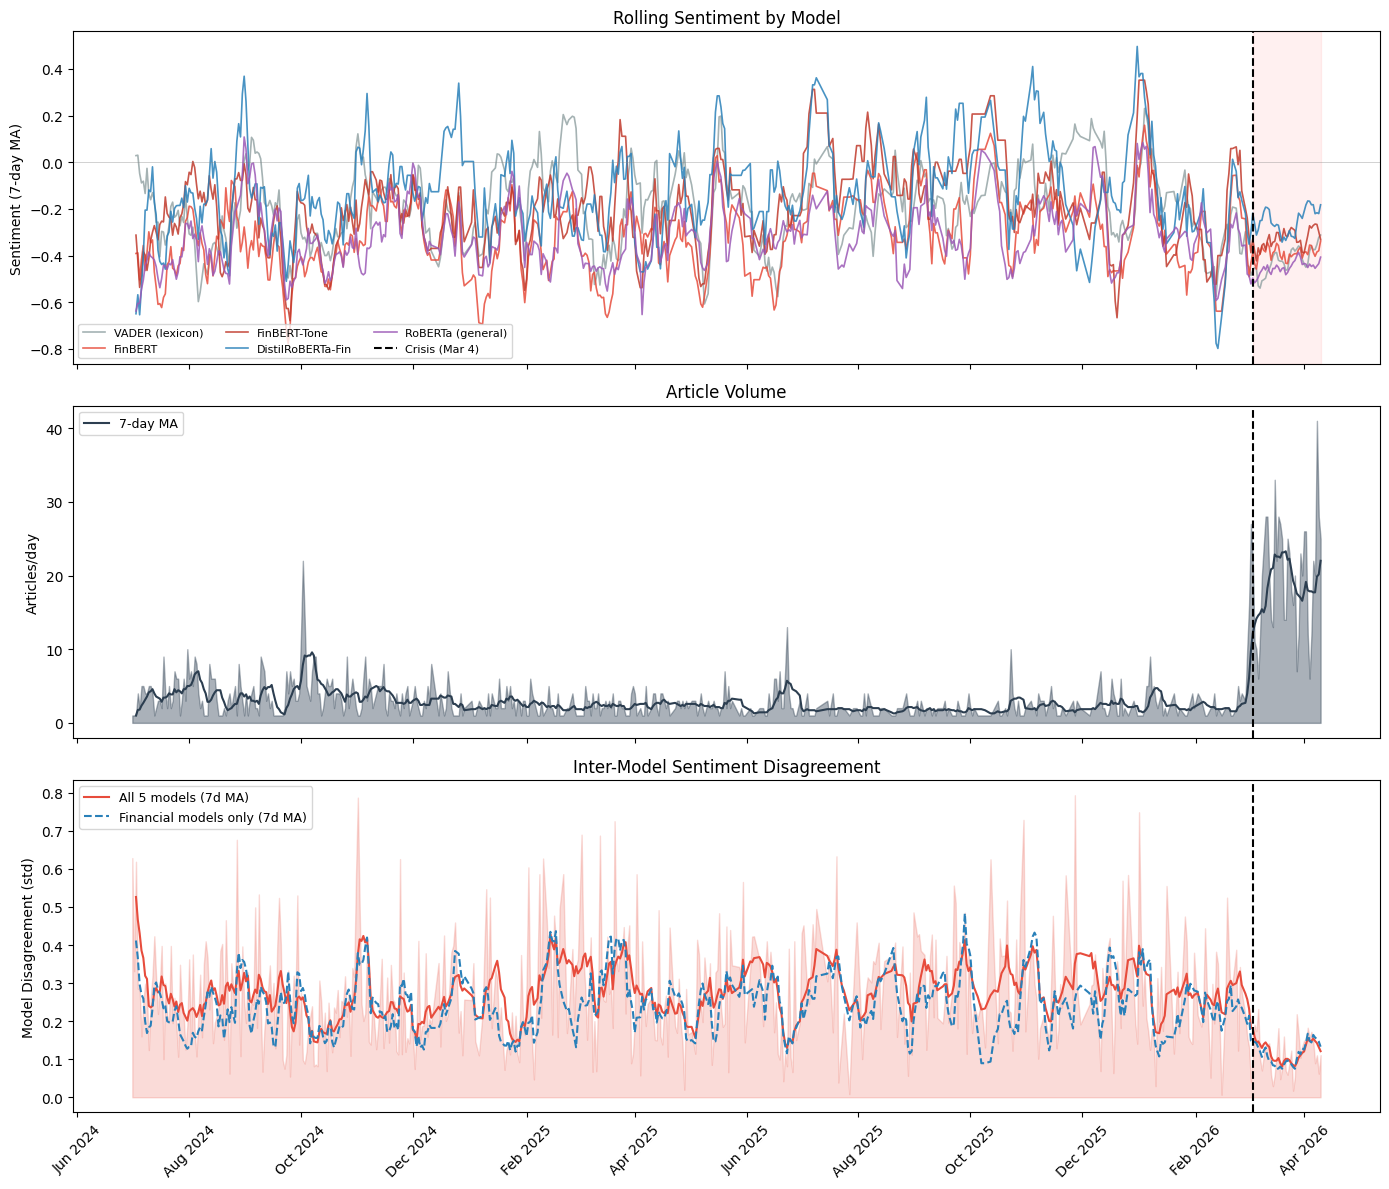

In [26]:
# Full timeline
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

ax = axes[0]
for m in MODELS:
    ax.plot(daily.index, daily[f"{m}_7d"], label=labels[m], color=colors[m], linewidth=1.2, alpha=0.85)
ax.axvline(crisis_dt, color="black", linestyle="--", linewidth=1.5, label="Crisis (Mar 4)")
ax.axvspan(crisis_dt, daily.index.max(), alpha=0.06, color="red")
ax.set_ylabel("Sentiment (7-day MA)")
ax.set_title("Rolling Sentiment by Model")
ax.legend(loc="lower left", ncol=3, fontsize=8)
ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5)

ax = axes[1]
ax.fill_between(daily.index, daily["article_count"], alpha=0.4, color="#2c3e50")
ax.plot(daily.index, daily["volume_7d"], color="#2c3e50", linewidth=1.5, label="7-day MA")
ax.axvline(crisis_dt, color="black", linestyle="--", linewidth=1.5)
ax.set_ylabel("Articles/day")
ax.set_title("Article Volume")
ax.legend(fontsize=9)

ax = axes[2]
ax.fill_between(daily.index, daily["model_disagreement"], alpha=0.2, color="#e74c3c")
ax.plot(daily.index, daily["disagreement_7d"], color="#e74c3c", linewidth=1.5, label="All 5 models (7d MA)")
ax.plot(daily.index, daily["fin_disagreement_7d"], color="#2980b9", linewidth=1.5,
        linestyle="--", label="Financial models only (7d MA)")
ax.axvline(crisis_dt, color="black", linestyle="--", linewidth=1.5)
ax.set_ylabel("Model Disagreement (std)")
ax.set_title("Inter-Model Sentiment Disagreement")
ax.legend(fontsize=9)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/early_warning_overview.png", dpi=150)
plt.show()

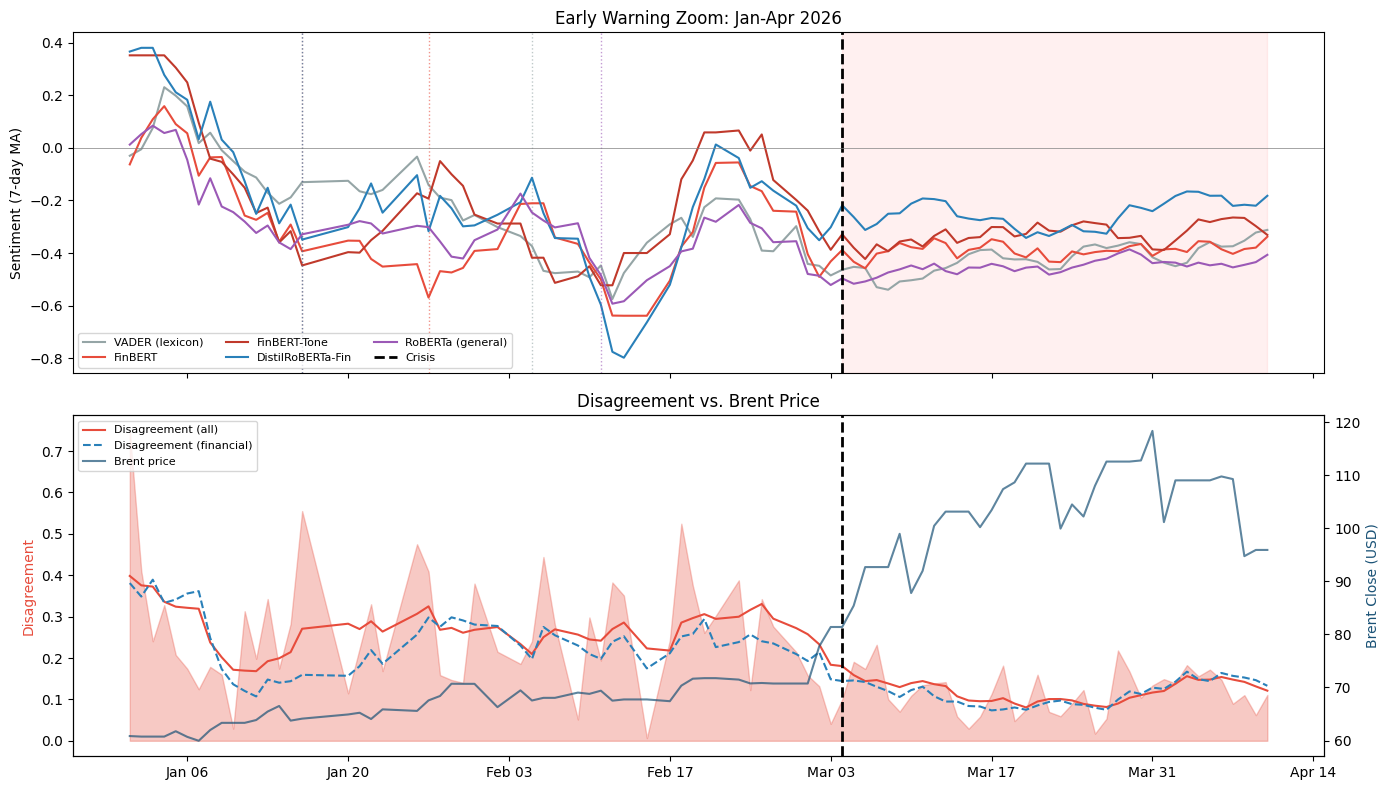

In [27]:
# Zoomed: Jan-Apr 2026
zoom = daily[(daily.index >= "2026-01-01") & (daily.index <= "2026-04-15")]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
for m in MODELS:
    ax.plot(zoom.index, zoom[f"{m}_7d"], label=labels[m], color=colors[m], linewidth=1.5)
    ew = early_warning_dates.get(m, {})
    if ew.get("first_alarm"):
        alarm_dt = pd.to_datetime(ew["first_alarm"])
        if alarm_dt >= zoom.index.min():
            ax.axvline(alarm_dt, color=colors[m], linestyle=":", alpha=0.6, linewidth=1)

ax.axvline(crisis_dt, color="black", linestyle="--", linewidth=2, label="Crisis")
ax.axvspan(crisis_dt, zoom.index.max(), alpha=0.06, color="red")
ax.set_ylabel("Sentiment (7-day MA)")
ax.set_title("Early Warning Zoom: Jan-Apr 2026")
ax.legend(loc="lower left", ncol=3, fontsize=8)
ax.axhline(0, color="gray", linewidth=0.5)

ax = axes[1]
ax.fill_between(zoom.index, zoom["model_disagreement"], alpha=0.3, color="#e74c3c")
ax.plot(zoom.index, zoom["disagreement_7d"], color="#e74c3c", linewidth=1.5, label="Disagreement (all)")
ax.plot(zoom.index, zoom["fin_disagreement_7d"], color="#2980b9", linewidth=1.5,
        linestyle="--", label="Disagreement (financial)")
ax.set_ylabel("Disagreement", color="#e74c3c")

ax2 = ax.twinx()
ax2.plot(zoom.index, zoom["brent_close"], color="#1a5276", linewidth=1.5, alpha=0.7, label="Brent price")
ax2.set_ylabel("Brent Close (USD)", color="#1a5276")

ax.axvline(crisis_dt, color="black", linestyle="--", linewidth=2)
ax.set_title("Disagreement vs. Brent Price")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/early_warning_zoom.png", dpi=150)
plt.show()

---
## 4. RQ2 — Disagreement Predicts Volatility?

In [28]:
print("=" * 60)
print("CORRELATION: Features vs Next-Day Volatility")
print("=" * 60)

features_to_test = [
    ("model_disagreement", "All-model disagreement"),
    ("fin_model_disagreement", "Financial-model disagreement"),
    ("disagreement_7d", "All-model disagreement (7d MA)"),
    ("fin_disagreement_7d", "Fin-model disagreement (7d MA)"),
    ("avg_article_disagreement", "Avg per-article disagreement"),
    ("avg_fin_article_disagreement", "Avg fin per-article disagreement"),
    ("article_count", "Daily article count"),
    ("volume_7d", "7-day volume MA"),
]
for m in MODELS:
    features_to_test.append((f"{m}_mean", f"{labels[m]} daily mean"))

results = []
for col, lbl in features_to_test:
    temp = daily[[col, "next_day_volatility"]].dropna()
    if len(temp) < 10:
        continue
    r, p = stats.pearsonr(temp[col], temp["next_day_volatility"])
    sr, sp = stats.spearmanr(temp[col], temp["next_day_volatility"])
    results.append({
        "feature": lbl, "pearson_r": round(r, 4), "pearson_p": round(p, 4),
        "spearman_r": round(sr, 4), "spearman_p": round(sp, 4),
        "significant": "*" if p < 0.05 else "",
    })

results_df = pd.DataFrame(results).sort_values("pearson_r", ascending=False, key=abs)
results_df

CORRELATION: Features vs Next-Day Volatility


,feature,pearson_r,pearson_p,spearman_r,spearman_p,significant
7,7-day volume MA,0.7583,0.0000,0.4285,0.0000,*
6,Daily article count,0.6668,0.0000,0.3120,0.0000,*
2,All-model disagreement (7d MA),-0.5193,0.0000,-0.3891,0.0000,*
3,Fin-model disagreement (7d MA),-0.3871,0.0000,-0.3188,0.0000,*
0,All-model disagreement,-0.2576,0.0000,-0.2144,0.0000,*
1,Financial-model disagreement,-0.1516,0.0004,-0.1165,0.0065,*
8,VADER (lexicon) daily mean,-0.1142,0.0076,-0.0731,0.0882,*
10,FinBERT-Tone daily mean,-0.0954,0.0259,-0.0975,0.0228,*
11,DistilRoBERTa-Fin daily mean,-0.0807,0.0598,-0.0956,0.0257,
12,RoBERTa (general) daily mean,-0.0764,0.0748,-0.0161,0.7083,


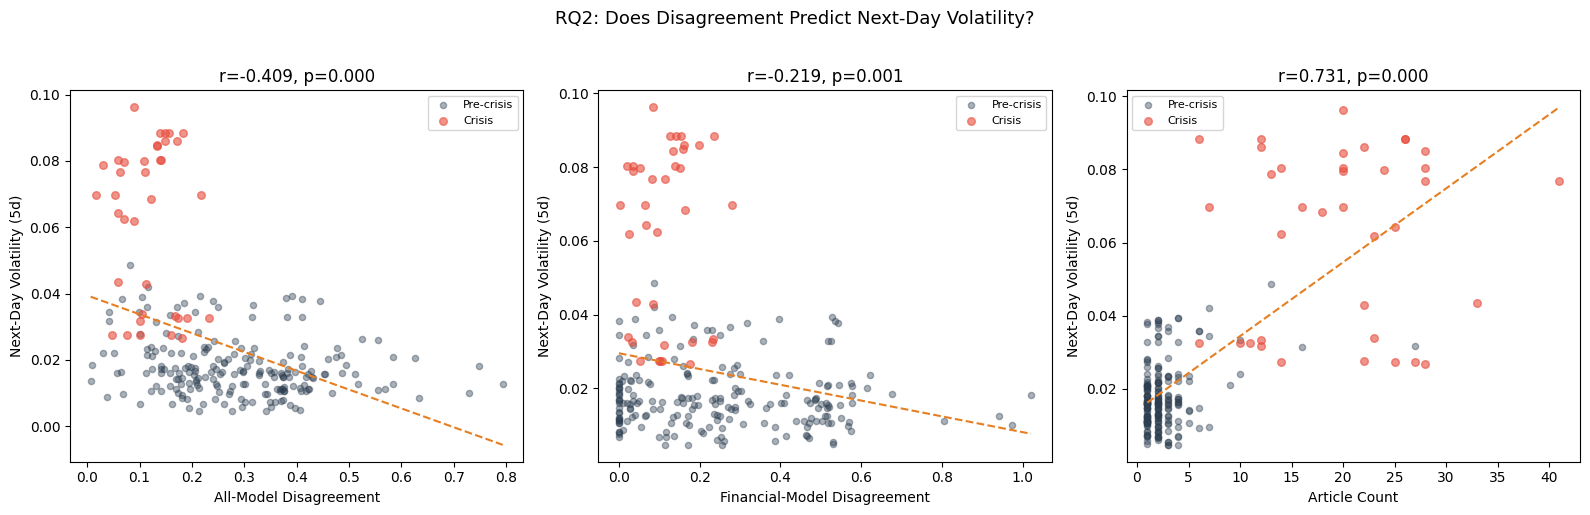

In [29]:
# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ("model_disagreement", "All-Model Disagreement"),
    ("fin_model_disagreement", "Financial-Model Disagreement"),
    ("article_count", "Article Count"),
]
plot_df = daily[daily.index >= "2025-06-01"].copy()

for ax, (x_col, xlabel) in zip(axes, pairs):
    temp = plot_df[[x_col, "next_day_volatility"]].dropna()
    cm = temp.index >= crisis_dt

    ax.scatter(temp.loc[~cm, x_col], temp.loc[~cm, "next_day_volatility"],
               alpha=0.4, s=20, color="#2c3e50", label="Pre-crisis")
    ax.scatter(temp.loc[cm, x_col], temp.loc[cm, "next_day_volatility"],
               alpha=0.6, s=30, color="#e74c3c", label="Crisis")

    z = np.polyfit(temp[x_col], temp["next_day_volatility"], 1)
    x_s = np.sort(temp[x_col])
    ax.plot(x_s, np.poly1d(z)(x_s), "--", color="#e67e22", linewidth=1.5)

    r, pv = stats.pearsonr(temp[x_col], temp["next_day_volatility"])
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Next-Day Volatility (5d)")
    ax.set_title(f"r={r:.3f}, p={pv:.3f}")
    ax.legend(fontsize=8)

plt.suptitle("RQ2: Does Disagreement Predict Next-Day Volatility?", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("plots/disagreement_vs_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Model Agreement Heatmaps

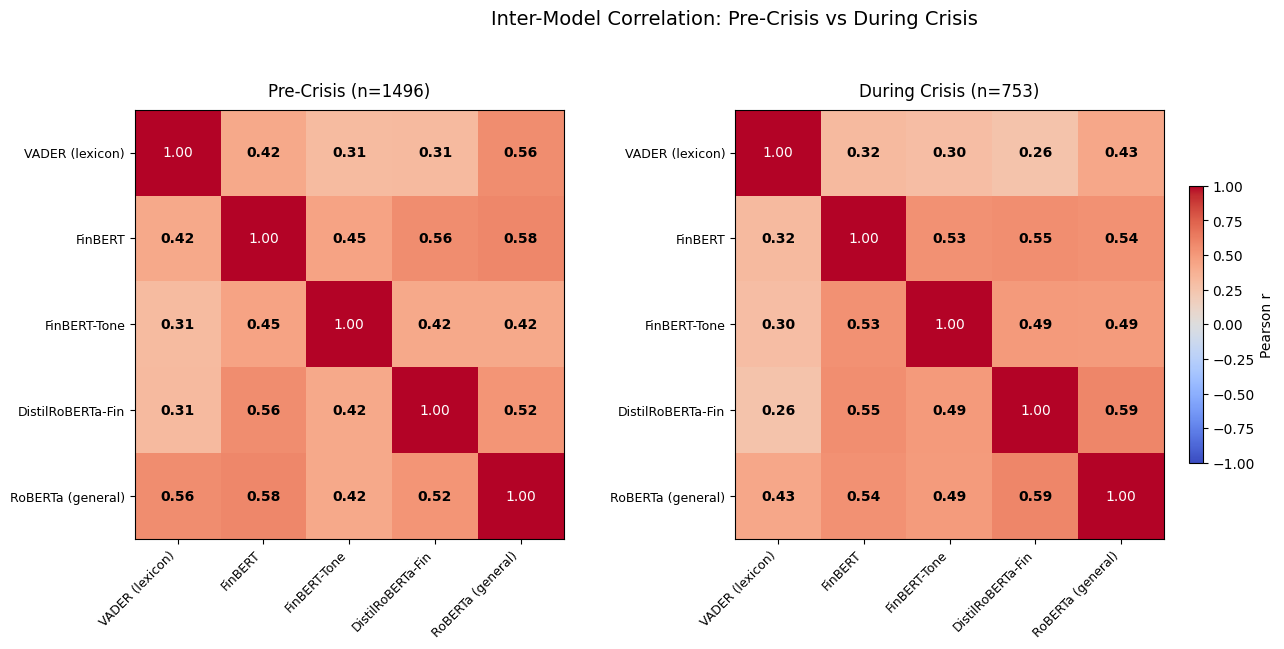

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"wspace": 0.4})

pre = df[df["date"] < pd.to_datetime(CRISIS_DATE).date()]
post = df[df["date"] >= pd.to_datetime(CRISIS_DATE).date()]
display_labels = [labels[m] for m in MODELS]

for ax, subset, title in [(axes[0], pre, "Pre-Crisis"), (axes[1], post, "During Crisis")]:
    corr = subset[MODELS].corr()
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(MODELS)))
    ax.set_yticks(range(len(MODELS)))
    ax.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(display_labels, fontsize=9)
    ax.set_title(f"{title} (n={len(subset)})", fontsize=12, pad=10)

    for i in range(len(MODELS)):
        for j in range(len(MODELS)):
            val = corr.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10,
                    fontweight="bold" if i != j else "normal",
                    color="white" if abs(val) > 0.6 else "black")

fig.colorbar(im, ax=axes, shrink=0.6, label="Pearson r", pad=0.02)
plt.suptitle("Inter-Model Correlation: Pre-Crisis vs During Crisis", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plots/model_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()